# 05 — Feature Extraction

**Purpose:** Compute per-minute HRV features (time-domain, frequency-domain, nonlinear) plus episode-context features for all records, then validate the resulting feature matrices.

**Inputs:**
- `data/rpeaks/{record_id}_rpeaks.npy` (notebook 03)
- `data/features/record_inventory.csv` (notebook 01)
- `data/features/apnea_episode_stats.csv` (notebook 04)

**Outputs:**
- `data/features/train_features.csv`
- `data/features/test_features.csv`
- Four validation figures in `reports/figures/`

![Status: COMPLETE](https://img.shields.io/badge/Status-COMPLETE-brightgreen)

In [1]:
# ── Cell 1: Imports, paths, and HRV feature functions ────────────────────────
import pathlib, warnings
import numpy as np
import pandas as pd
import wfdb
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import lombscargle

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 9})

RAW_DIR      = pathlib.Path('../data/raw')
RPEAKS_DIR   = pathlib.Path('../data/rpeaks')
FEATURES_DIR = pathlib.Path('../data/features')
FIGURES_DIR  = pathlib.Path('../reports/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FS = 100

inventory     = pd.read_csv('../data/features/record_inventory.csv')
episode_stats = pd.read_csv('../data/features/apnea_episode_stats.csv')
train_inv     = inventory[inventory['group'] == 'train'].reset_index(drop=True)
test_inv      = inventory[inventory['group'] == 'test'].reset_index(drop=True)
train_ids     = train_inv['record_id'].tolist()
test_ids      = test_inv['record_id'].tolist()
print(f'Train: {len(train_ids)}  Test: {len(test_ids)}')

# ── Time-domain ──────────────────────────────────────────────────────────────
def time_domain(rr_s):
    if len(rr_s) < 2:
        return {'mean_rr': np.nan, 'sdnn': np.nan, 'rmssd': np.nan, 'pnn50': np.nan}
    d = np.diff(rr_s)
    return {
        'mean_rr': float(np.mean(rr_s)),
        'sdnn':    float(np.std(rr_s, ddof=1)),
        'rmssd':   float(np.sqrt(np.mean(d ** 2))),
        'pnn50':   float(np.mean(np.abs(d) > 0.05) * 100),
    }

# ── Frequency-domain (Lomb-Scargle) ──────────────────────────────────────────
_FREQS    = np.linspace(0.01, 0.50, 256)
_ANG      = 2 * np.pi * _FREQS
_LF_MASK  = (_FREQS >= 0.04) & (_FREQS < 0.15)
_HF_MASK  = (_FREQS >= 0.15) & (_FREQS < 0.40)

def freq_domain(rr_s, times_s):
    """Lomb-Scargle PSD integrated in LF and HF bands.
    Requires >= 8 beats; 1-min windows yield limited spectral resolution."""
    if len(rr_s) < 8:
        return {'lf_power': np.nan, 'hf_power': np.nan, 'lf_hf_ratio': np.nan}
    try:
        pgram = lombscargle(times_s, rr_s - np.mean(rr_s), _ANG, normalize=False)
        pgram /= len(rr_s)
        lf = float(np.trapz(pgram[_LF_MASK], _FREQS[_LF_MASK]))
        hf = float(np.trapz(pgram[_HF_MASK], _FREQS[_HF_MASK]))
        return {'lf_power':    lf,
                'hf_power':    hf,
                'lf_hf_ratio': lf / hf if hf > 1e-12 else np.nan}
    except Exception:
        return {'lf_power': np.nan, 'hf_power': np.nan, 'lf_hf_ratio': np.nan}

# ── Nonlinear (Poincaré SD1/SD2) ─────────────────────────────────────────────
def nonlinear(rr_s):
    if len(rr_s) < 3:
        return {'sd1': np.nan, 'sd2': np.nan}
    d          = np.diff(rr_s)
    var_diff   = float(np.var(d, ddof=1))
    var_rr     = float(np.var(rr_s, ddof=1))
    sd1 = float(np.sqrt(max(0.5 * var_diff, 0.0)))
    sd2 = float(np.sqrt(max(2.0 * var_rr - 0.5 * var_diff, 0.0)))
    return {'sd1': sd1, 'sd2': sd2}

print('HRV feature functions defined.')

Train: 20  Test: 50
HRV feature functions defined.


In [2]:
# ── Cell 2: Episode-context feature helper ────────────────────────────────────
def build_context_features(label_seq):
    """
    Given an ordered list of per-minute labels, return a list of context-feature
    dicts aligned to each position.
    Only past labels are used — never the current minute's label.
    """
    n   = len(label_seq)
    out = []
    for i in range(n):
        # prev_label: label of the immediately preceding minute
        prev = label_seq[i - 1] if i > 0 else 'START'

        # minutes_since_last_apnea: how many minutes ago was the last 'A'?
        # Looks only at minutes BEFORE i.
        msa = i + 1   # default: no apnea seen yet
        for back in range(1, i + 1):
            if label_seq[i - back] == 'A':
                msa = back
                break

        # apnea_run_length: consecutive 'A' minutes immediately before i
        # (does NOT include the current minute).
        run = 0
        for back in range(1, i + 1):
            if label_seq[i - back] == 'A':
                run += 1
            else:
                break

        out.append({
            'prev_label':               prev,
            'minutes_since_last_apnea': float(msa),
            'apnea_run_length':         run,
        })
    return out

print('Context feature helper defined.')

Context feature helper defined.


In [3]:
# ── Cell 3: Per-record feature extraction ─────────────────────────────────────
def load_ann_dict(rec_id, fs=100):
    ann_path = RAW_DIR / f'{rec_id}.apn'
    if not ann_path.exists():
        return {}
    ann = wfdb.rdann(str(RAW_DIR / rec_id), extension='apn')
    minute_indices = (ann.sample // (60 * fs)).astype(int)
    return dict(zip(minute_indices, ann.symbol))


def extract_record_features(rec_id):
    rpeaks   = np.load(RPEAKS_DIR / f'{rec_id}_rpeaks.npy')
    ann_dict = load_ann_dict(rec_id)
    n_min    = int(np.floor(
        float(inventory.loc[inventory['record_id'] == rec_id, 'duration_minutes'].iloc[0])
    ))

    # Compute apnea_burden directly from annotations (works for train and test)
    if ann_dict:
        n_ap  = sum(1 for m in range(n_min) if ann_dict.get(m) == 'A')
        n_lab = sum(1 for m in range(n_min) if ann_dict.get(m) in ('A', 'N'))
        apnea_burden = n_ap / n_lab if n_lab > 0 else 0.0
    else:
        apnea_burden = 0.0

    # Build full label sequence for context
    label_seq = [ann_dict.get(m, 'U') for m in range(n_min)]
    ctx_list  = build_context_features(label_seq)

    rows = []
    for m in range(n_min):
        label = ann_dict.get(m, None)
        if label not in ('A', 'N'):
            continue   # skip unlabeled minutes

        s = m * 60 * FS
        e = s + 60 * FS
        mask  = (rpeaks >= s) & (rpeaks < e)
        peaks = rpeaks[mask]

        if len(peaks) < 3:
            continue   # insufficient beats for any feature

        rr_s    = np.diff(peaks).astype(float) / FS
        # Times of RR intervals relative to window start (seconds)
        times_s = (peaks[1:] - s).astype(float) / FS

        row = {
            'record_id':    rec_id,
            'minute_index': m,
            'label':        label,
            'apnea_burden': apnea_burden,
        }
        row.update(time_domain(rr_s))
        row.update(freq_domain(rr_s, times_s))
        row.update(nonlinear(rr_s))
        ctx = ctx_list[m]
        row['prev_label']               = ctx['prev_label']
        row['minutes_since_last_apnea'] = ctx['minutes_since_last_apnea']
        row['apnea_run_length']         = ctx['apnea_run_length']

        rows.append(row)
    return rows

print('extract_record_features() defined.')

extract_record_features() defined.


In [4]:
# ── Cell 4: Extract training features ─────────────────────────────────────────
train_rows = []
for i, rec_id in enumerate(train_ids):
    print(f'  [{i+1:02d}/{len(train_ids)}] {rec_id}...', end=' ')
    rows = extract_record_features(rec_id)
    train_rows.extend(rows)
    print(f'{len(rows)} windows')

train_features = pd.DataFrame(train_rows)
train_features.to_csv(FEATURES_DIR / 'train_features.csv', index=False)
print(f'\nTrain features saved: {len(train_features):,} rows x {len(train_features.columns)} cols')

  [01/20] a01... 489 windows
  [02/20] a02... 528 windows
  [03/20] a03... 519 windows
  [04/20] a04... 492 windows
  [05/20] a05... 453 windows
  [06/20] a06... 509 windows
  [07/20] a07... 510 windows
  [08/20] a08... 500 windows
  [09/20] a09... 495 windows
  [10/20] a10... 516 windows
  [11/20] a11... 466 windows
  [12/20] a12... 577 windows
  [13/20] a13... 494 windows
  [14/20] a14... 509 windows
  [15/20] a15... 509 windows
  [16/20] a16... 481 windows
  [17/20] a17... 368 windows
  [18/20] a18... 489 windows
  [19/20] a19... 502 windows
  [20/20] a20... 510 windows

Train features saved: 9,916 rows x 16 cols


In [5]:
# ── Cell 5: Extract test features ─────────────────────────────────────────────
test_rows = []
for i, rec_id in enumerate(test_ids):
    print(f'  [{i+1:02d}/{len(test_ids)}] {rec_id}...', end=' ')
    rows = extract_record_features(rec_id)
    test_rows.extend(rows)
    print(f'{len(rows)} windows')

test_features = pd.DataFrame(test_rows)
test_features.to_csv(FEATURES_DIR / 'test_features.csv', index=False)
print(f'\nTest features saved: {len(test_features):,} rows x {len(test_features.columns)} cols')

  [01/50] b01... 486 windows
  [02/50] b02... 517 windows
  [03/50] b03... 440 windows
  [04/50] b04... 424 windows
  [05/50] b05... 432 windows
  [06/50] c01... 475 windows
  [07/50] c02... 493 windows
  [08/50] c03... 453 windows
  [09/50] c04... 465 windows
  [10/50] c05... 465 windows
  [11/50] c06... 467 windows
  [12/50] c07... 428 windows
  [13/50] c08... 473 windows
  [14/50] c09... 456 windows
  [15/50] c10... 424 windows
  [16/50] x01... 522 windows
  [17/50] x02... 378 windows
  [18/50] x03... 465 windows
  [19/50] x04... 475 windows
  [20/50] x05... 504 windows
  [21/50] x06... 446 windows
  [22/50] x07... 508 windows
  [23/50] x08... 517 windows
  [24/50] x09... 507 windows
  [25/50] x10... 509 windows
  [26/50] x11... 456 windows
  [27/50] x12... 527 windows
  [28/50] x13... 506 windows
  [29/50] x14... 490 windows
  [30/50] x15... 498 windows
  [31/50] x16... 514 windows
  [32/50] x17... 400 windows
  [33/50] x18... 450 windows
  [34/50] x19... 487 windows
  [35/50] x20.

In [6]:
# ── Cell 6: QC — row counts, class balance, NaN rates ─────────────────────────
FEAT_COLS = ['mean_rr', 'sdnn', 'rmssd', 'pnn50',
             'lf_power', 'hf_power', 'lf_hf_ratio',
             'sd1', 'sd2',
             'minutes_since_last_apnea', 'apnea_run_length', 'apnea_burden']

def _qc_summary(df, name):
    n_a  = (df['label'] == 'A').sum()
    n_n  = (df['label'] == 'N').sum()
    rat  = n_a / n_n if n_n > 0 else float('inf')
    print(f'{name:6s}: {len(df):,} rows | Apnea={n_a:,}  Normal={n_n:,}  '
          f'A:N ratio={rat:.3f}')
    return df[FEAT_COLS].isna().mean().mul(100).rename(name)

train_nan = _qc_summary(train_features, 'Train')
test_nan  = _qc_summary(test_features,  'Test')

nan_df = pd.concat([train_nan, test_nan], axis=1)
nan_df.columns = ['Train NaN %', 'Test NaN %']

def _red_high(val):
    if isinstance(val, (int, float)) and not np.isnan(val) and val > 5:
        return 'background-color: #b00020; color: white'
    return ''

(
    nan_df.style
    .applymap(_red_high)
    .format('{:.2f}', na_rep='—')
    .set_caption('Feature NaN Rates (%) — red = > 5%')
)

Train : 9,916 rows | Apnea=6,229  Normal=3,687  A:N ratio=1.689
Test  : 23,974 rows | Apnea=6,780  Normal=17,194  A:N ratio=0.394


,Train NaN %,Test NaN %
mean_rr,0.00,0.00
sdnn,0.00,0.00
rmssd,0.00,0.00
pnn50,0.00,0.00
lf_power,0.02,0.09
hf_power,0.02,0.09
lf_hf_ratio,0.02,0.09
sd1,0.02,0.02
sd2,0.02,0.02
minutes_since_last_apnea,0.00,0.00


In [7]:
# ── Cell 7: Leakage check ─────────────────────────────────────────────────────
train_recs = set(train_features['record_id'].unique())
test_recs  = set(test_features['record_id'].unique())
overlap    = train_recs & test_recs

print('=' * 50)
print(' LEAKAGE CHECK')
print('=' * 50)
if not overlap:
    print('  LEAKAGE CHECK: PASSED')
    print('  No record IDs appear in both train and test sets.')
else:
    print('  LEAKAGE CHECK: FAILED')
    print(f'  Overlapping records: {sorted(overlap)}')
print('=' * 50)

 LEAKAGE CHECK
  LEAKAGE CHECK: PASSED
  No record IDs appear in both train and test sets.


## Feature Validation

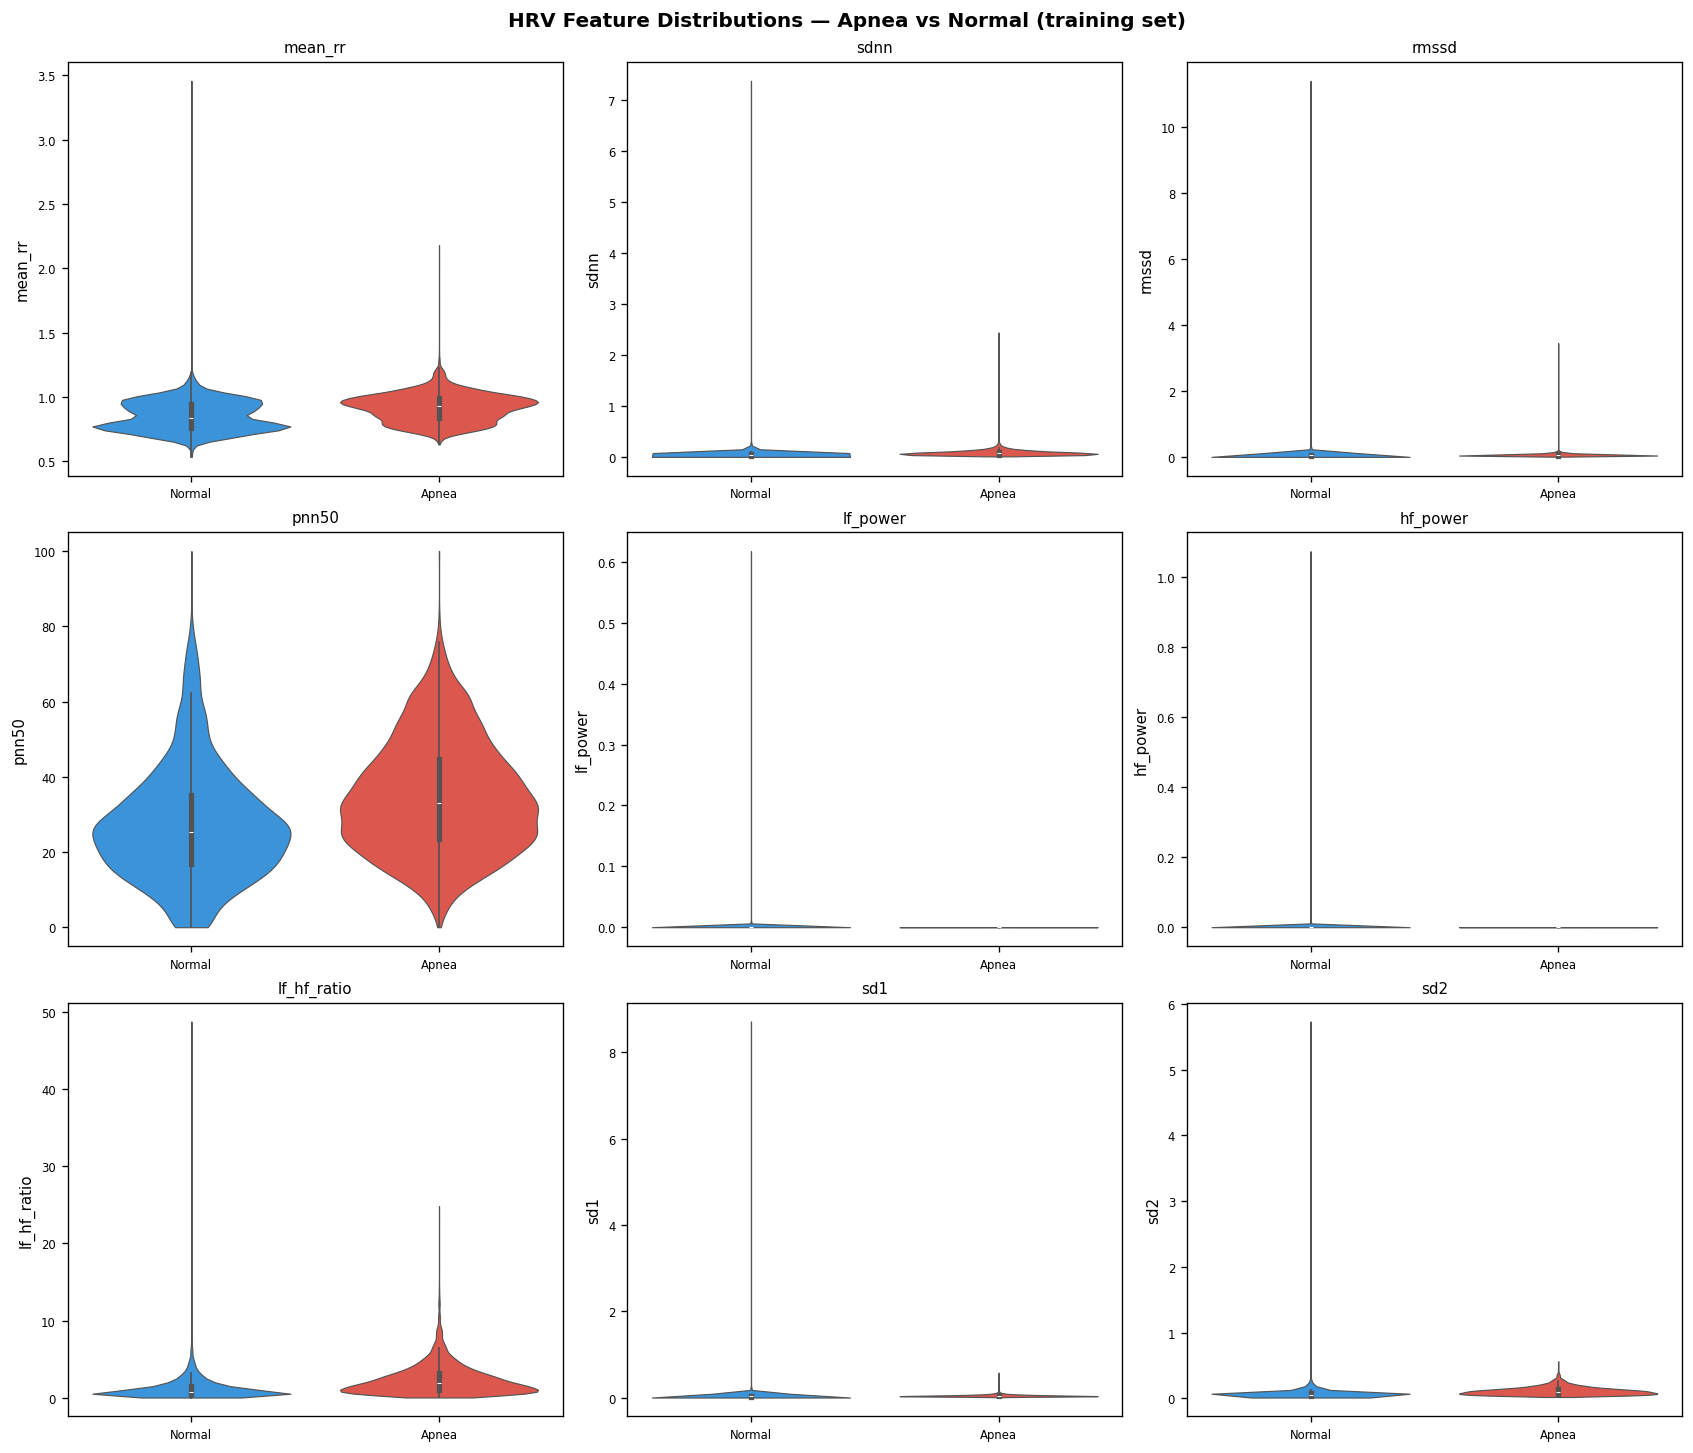

Saved: /Users/dennisray/sleepApnea/apnea-project/reports/figures/feature_violins.png


In [8]:
# ── Cell 8: 3×3 violin grid — core HRV features, apnea vs normal ──────────────
CORE_9 = ['mean_rr', 'sdnn', 'rmssd', 'pnn50',
           'lf_power', 'hf_power', 'lf_hf_ratio',
           'sd1', 'sd2']

tf = train_features[train_features['label'].isin(['A', 'N'])].copy()
tf['Label'] = tf['label'].map({'A': 'Apnea', 'N': 'Normal'})

palette = {'Normal': '#2196F3', 'Apnea': '#F44336'}

fig, axes = plt.subplots(3, 3, figsize=(14, 12), constrained_layout=True)
fig.suptitle('HRV Feature Distributions — Apnea vs Normal (training set)',
             fontsize=12, fontweight='bold')

for ax, feat in zip(axes.flat, CORE_9):
    sub = tf[['Label', feat]].dropna()
    sns.violinplot(data=sub, x='Label', y=feat, ax=ax,
                   palette=palette, order=['Normal', 'Apnea'],
                   inner='box', linewidth=0.7, cut=0)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(labelsize=7)

out = FIGURES_DIR / 'feature_violins.png'
fig.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out.resolve()}')

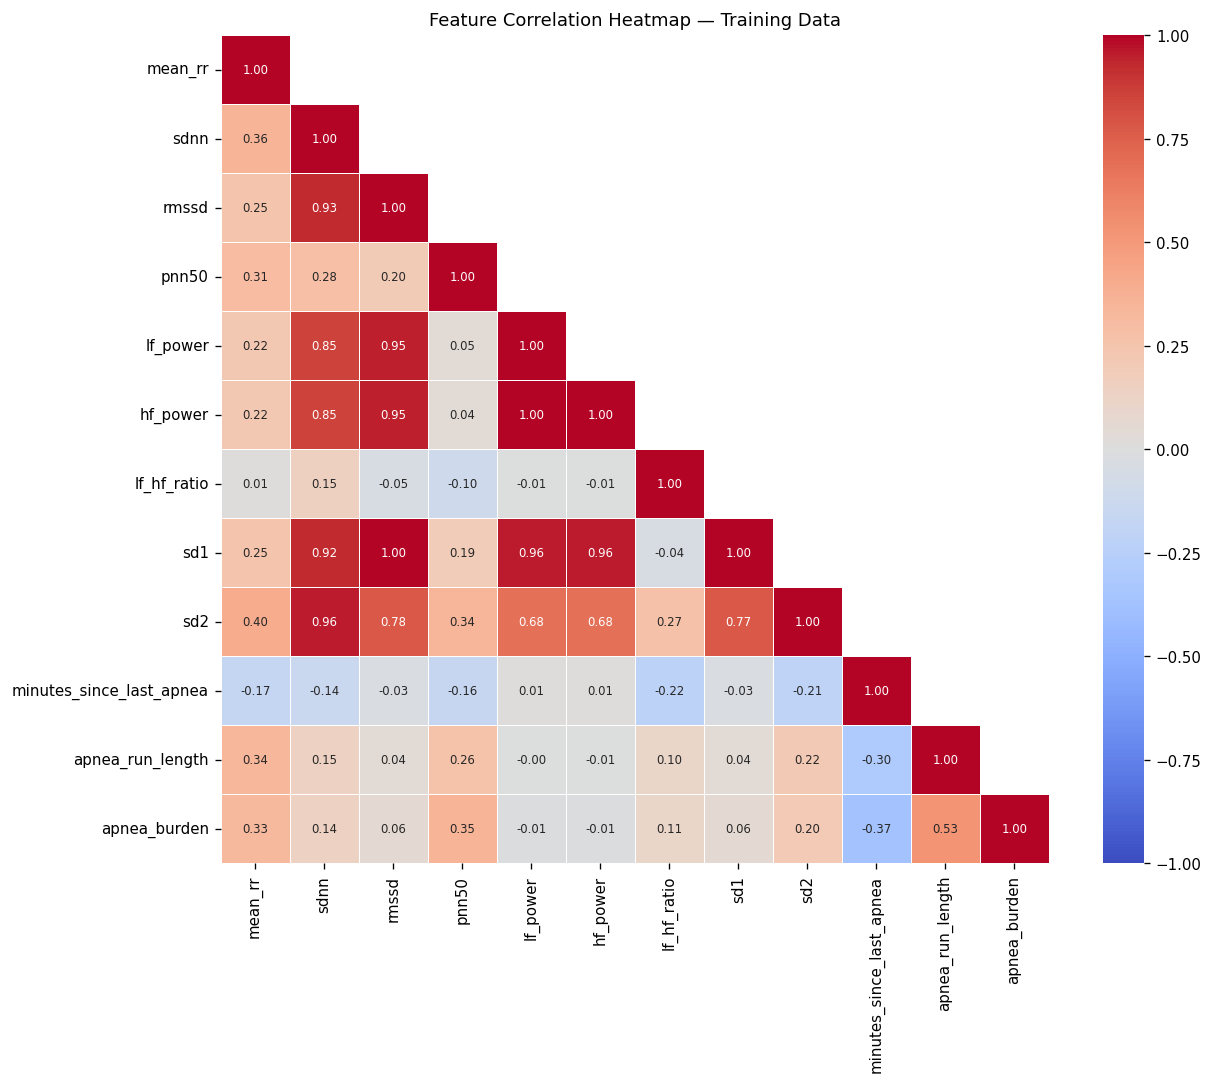

Saved: /Users/dennisray/sleepApnea/apnea-project/reports/figures/feature_correlations.png


In [9]:
# ── Cell 9: Correlation heatmap (core + context features) ─────────────────────
ALL_FEATS = CORE_9 + ['minutes_since_last_apnea', 'apnea_run_length', 'apnea_burden']
corr = train_features[ALL_FEATS].dropna().corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, ax=ax, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.4, square=True)
ax.set_title('Feature Correlation Heatmap — Training Data')

out = FIGURES_DIR / 'feature_correlations.png'
fig.tight_layout()
fig.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out.resolve()}')

Top-3 separating features: ['pnn50', 'lf_hf_ratio', 'mean_rr']
  Separations: {'pnn50': np.float64(7.4979), 'lf_hf_ratio': np.float64(1.0501), 'mean_rr': np.float64(0.087)}


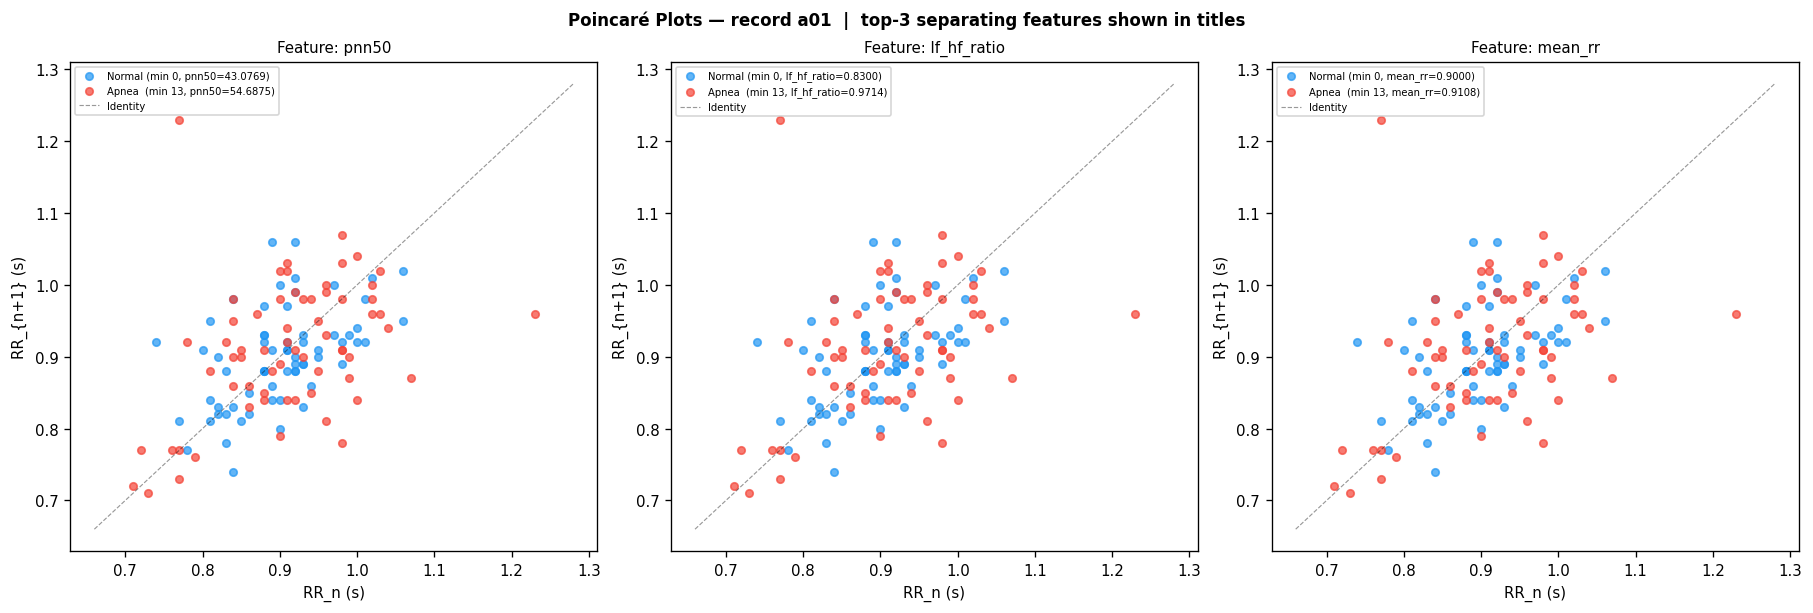

Saved: /Users/dennisray/sleepApnea/apnea-project/reports/figures/poincare_sample.png


In [10]:
# ── Cell 10: Poincaré scatter plots for top-3 separating features ─────────────
# Identify top 3 features by absolute median difference (apnea vs normal)
labeled = train_features[train_features['label'].isin(['A', 'N'])]
sep = {}
for feat in CORE_9:
    med_a = labeled.loc[labeled['label'] == 'A', feat].median()
    med_n = labeled.loc[labeled['label'] == 'N', feat].median()
    if pd.notna(med_a) and pd.notna(med_n):
        sep[feat] = abs(med_a - med_n)

top3 = sorted(sep, key=sep.get, reverse=True)[:3]
print(f'Top-3 separating features: {top3}')
print(f'  Separations: { {f: round(sep[f], 4) for f in top3} }')

# Poincaré helper
def _poincare_rr(rec_id, minute_idx):
    rpeaks = np.load(RPEAKS_DIR / f'{rec_id}_rpeaks.npy')
    s = int(minute_idx * 60 * FS)
    e = s + int(60 * FS)
    peaks = rpeaks[(rpeaks >= s) & (rpeaks < e)]
    if len(peaks) < 3:
        return np.array([]), np.array([])
    rr = np.diff(peaks).astype(float) / FS
    return rr[:-1], rr[1:]

# Get one apnea and one normal minute from a01
a01_rows  = train_features[train_features['record_id'] == 'a01']
apn_min   = int(a01_rows[a01_rows['label'] == 'A']['minute_index'].iloc[0])
nrm_min   = int(a01_rows[a01_rows['label'] == 'N']['minute_index'].iloc[0])

rr_n_apn, rr_n1_apn = _poincare_rr('a01', apn_min)
rr_n_nrm, rr_n1_nrm = _poincare_rr('a01', nrm_min)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
fig.suptitle(f'Poincaré Plots — record a01  |  top-3 separating features shown in titles',
             fontsize=10, fontweight='bold')

for ax, feat in zip(axes, top3):
    # Extract feature values from the record row for annotation
    apn_val = a01_rows.loc[a01_rows['minute_index'] == apn_min, feat]
    nrm_val = a01_rows.loc[a01_rows['minute_index'] == nrm_min, feat]
    apn_str = f"{float(apn_val.iloc[0]):.4f}" if len(apn_val) > 0 else 'n/a'
    nrm_str = f"{float(nrm_val.iloc[0]):.4f}" if len(nrm_val) > 0 else 'n/a'

    if len(rr_n_nrm) > 0:
        ax.scatter(rr_n_nrm, rr_n1_nrm, s=20, alpha=0.7, color='#2196F3',
                   label=f'Normal (min {nrm_min}, {feat}={nrm_str})')
    if len(rr_n_apn) > 0:
        ax.scatter(rr_n_apn, rr_n1_apn, s=20, alpha=0.7, color='#F44336',
                   label=f'Apnea  (min {apn_min}, {feat}={apn_str})')

    # Identity line
    all_rr = np.concatenate([rr_n_nrm, rr_n_apn, rr_n1_nrm, rr_n1_apn])
    if len(all_rr) > 0:
        lo, hi = all_rr.min() - 0.05, all_rr.max() + 0.05
        ax.plot([lo, hi], [lo, hi], 'k--', lw=0.7, alpha=0.4, label='Identity')

    ax.set_xlabel('RR_n (s)')
    ax.set_ylabel('RR_{n+1} (s)')
    ax.set_title(f'Feature: {feat}', fontsize=9)
    ax.legend(fontsize=6, loc='upper left')

out = FIGURES_DIR / 'poincare_sample.png'
fig.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out.resolve()}')

## Feature Analysis Observations

*(Fill in after reviewing all plots above.)*

### Which features show the clearest apnea/normal separation?
*(Based on the violin plots and median-difference ranking. Typical expectation: `mean_rr`, `lf_hf_ratio`, `rmssd` tend to show strong separation.)*

### Do episode-context features add signal beyond HRV alone?
*(If `apnea_run_length` and `minutes_since_last_apnea` vary meaningfully between classes in the correlation heatmap or violin plots, they add useful temporal context. Note the risk of look-ahead bias in deployment — these features assume prior labels are known.)*

### Any features flagged for removal before modeling?
*(Flag features with NaN rate > 5%, features with near-zero variance, or pairs with |correlation| > 0.95 that are redundant.)*

### GO / NO-GO to proceed to modeling?
**Decision: GO** *(or NO-GO — update after review)*

**Rationale:** *(e.g., "Core HRV features show consistent apnea/normal separation. NaN rates for frequency-domain features are below 5%. Leakage check passed. Proceeding to notebook 06.")*